In [ ]:
import pandas as pd
from github_helper import from_github
import matplotlib.pyplot as plt

In [2]:
party_edges = pd.read_csv(from_github(f"/edges/party/all_party_edges_by_Period.csv")) 

In [ ]:
traditional_parties = ["Det Konservative Folkeparti", "Enhedslisten", "Liberal Alliance", "Radikale Venstre", "Socialdemokratiet", "Socialistisk Folkeparti", "Venstre", "Dansk Folkeparti"]

trad_parties = (party_edges['source'].isin(traditional_parties) & party_edges['target'].isin(traditional_parties))
df_trad = party_edges[trad_parties]


In [ ]:
def plot_edge_timeline(
    df_trad,
    topic,
    weight_threshold=0.5,
    periods=(66, 67, 68, 69, 70, 71),
    bar_color="#4C72B0"   # nicer blue
):
    df = df_trad.copy()

    # --- 1) Base filter: topic, periods, no self-edges ---
    base = df[
        (df["topic"] == topic) &
        (df["source"] != df["target"]) &
        (df["Period"].isin(periods))
    ].copy()

    if base.empty:
        print("No edges for this topic/period selection.")
        return

    # --- 2) Build edge label & alphabetical sorting ---
    base["edge"] = base["source"] + " – " + base["target"]
    base = base.sort_values(["source", "target"], ascending = False)

    edges = (base["source"] + " – " + base["target"]).unique().tolist()
    y_positions = {edge: i for i, edge in enumerate(edges)}

    # --- 3) Weight filter for drawing ---
    seg = base[base["weight"] >= weight_threshold].copy()

    # --- 4) Plot ----------------------------------------------------
    fig, ax = plt.subplots(figsize=(16, 10))

    for _, row in seg.sort_values(["edge", "Period"]).iterrows():
        edge = row["edge"]
        period = row["Period"]
        y = y_positions[edge]

        ax.broken_barh(
            [(period - 0.5, 1.0)],
            (y - 0.35, 0.7),
            facecolors=bar_color,
            edgecolors="black",
            linewidth=0.4
        )

    # --- 5) Axis formatting -----------------------------------------

    ax.set_yticks(range(len(edges)))
    ax.set_yticklabels(edges, ha="left")  # LEFT ALIGN

    # Shift labels slightly left so they don’t collide with the chart
    ax.tick_params(axis='y', pad=260)

    ax.set_xticks(list(periods))
    ax.set_xlim(min(periods) - 0.5, max(periods) + 0.5)

    ax.set_xlabel("Elective Periods", fontsize=12)
    # ax.set_ylabel("Party Pair (Edge)", fontsize=12)

    # Better title
    ax.set_title(
        f"Party Agreement on '{topic}' across periods, with threshold {weight_threshold:.0%} \n"
        "The segment is colored if the parties agreed",
        fontsize=16,
        pad=20
    )

    # Grid to make it easier to read across periods
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()


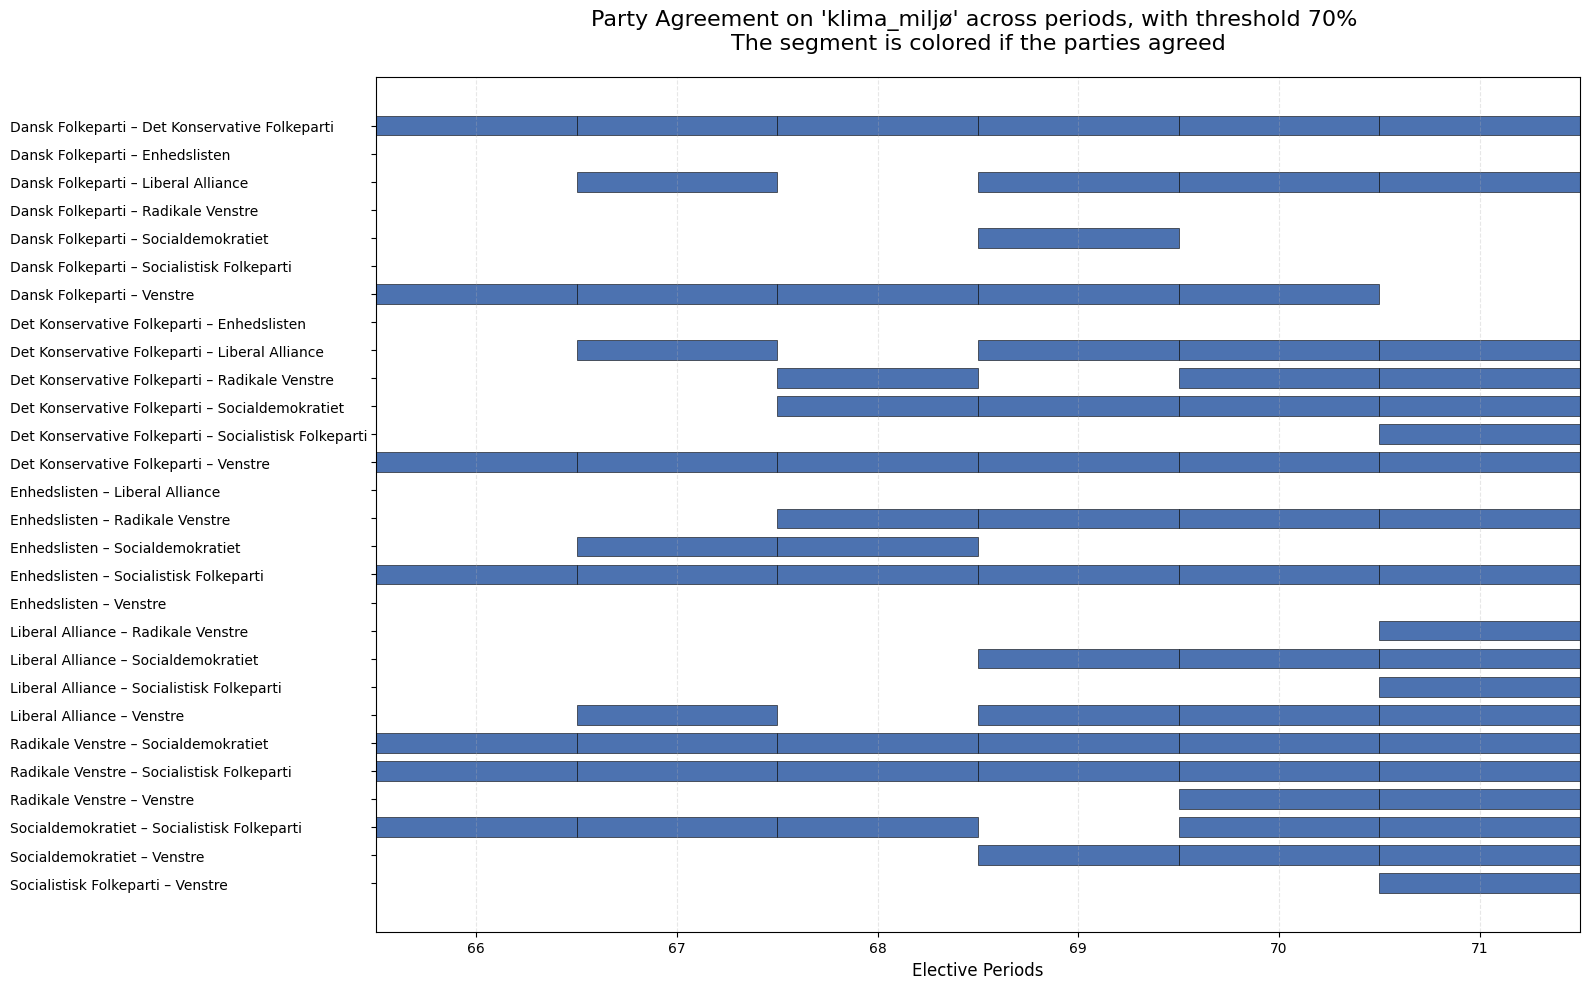

In [65]:
plot_edge_timeline(df_trad, topic="klima_miljø", weight_threshold=0.7)